# **DecodeLabs Project 1: Medical Health Indicator**

**Task 1: Dataset Generation & Understanding**

In [1]:
import pandas as pd

df = pd.read_csv('diabetes.csv')

# --- Task 1 Deliverables ---
print("--- DATASET SHAPE ---")
print(f"Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")

print("\n--- DETAILED METADATA & DATA TYPES ---")
print(df.info())

print("\n--- SAMPLE RECORDS (FIRST 5 ROWS) ---")
print(df.head())


--- DATASET SHAPE ---
Total Records: 768, Total Features: 9

--- DETAILED METADATA & DATA TYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- SAMPLE RECORDS (FIRST 5 ROWS) ---
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148            

**Task 2: Data Cleaning & Preprocessing**

In [2]:
# Identifying columns where a value of 0 is physically impossible
invalid_zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("--- UNCLEANED INVALIDS (COUNT OF ZEROS) ---")
for col in invalid_zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f" {col}: {zero_count} hidden missing values")

for col in invalid_zero_cols:
    df[col] = df[col].replace(0, float('nan'))

for col in invalid_zero_cols:
    col_median = df[col].median()
    df[col] = df[col].fillna(col_median)

# Checking for and eliminating duplicate entries
duplicate_count = df.duplicated().sum()
print(f"\n--- DUPLICATES CHECK ---")
print(f" Found duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(" Duplicates successfully removed!")

print("\n--- POST-CLEANING MISSING VALUES CHECK ---")
print(df[invalid_zero_cols].isnull().sum())


--- UNCLEANED INVALIDS (COUNT OF ZEROS) ---
 Glucose: 5 hidden missing values
 BloodPressure: 35 hidden missing values
 SkinThickness: 227 hidden missing values
 Insulin: 374 hidden missing values
 BMI: 11 hidden missing values

--- DUPLICATES CHECK ---
 Found duplicate rows: 0

--- POST-CLEANING MISSING VALUES CHECK ---
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**Task 3: Exploratory Data Analysis (EDA)**

In [3]:
print("--- DESCRIPTIVE STATISTIC SUMMARY ---")
summary_stats = df.describe().T
print(summary_stats[['mean', 'std', 'min', '50%', 'max']])

# Tracking Diabetes Target Distribution
print("\n--- OUTCOME DISTRIBUTION ---")
print(df['Outcome'].value_counts(normalize=True) * 100)

# Detecting Outliers using the Interquartile Range (IQR) method
print("\n--- OUTLIER PROFILE PER METRIC (IQR ANALYSIS) ---")
for col in df.columns[:-1]: # Exclude the binary outcome column
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f" {col:25}: Found {len(outliers):3} outliers")


--- DESCRIPTIVE STATISTIC SUMMARY ---
                                mean        std     min       50%     max
Pregnancies                 3.845052   3.369578   0.000    3.0000   17.00
Glucose                   121.656250  30.438286  44.000  117.0000  199.00
BloodPressure              72.386719  12.096642  24.000   72.0000  122.00
SkinThickness              29.108073   8.791221   7.000   29.0000   99.00
Insulin                   140.671875  86.383060  14.000  125.0000  846.00
BMI                        32.455208   6.875177  18.200   32.3000   67.10
DiabetesPedigreeFunction    0.471876   0.331329   0.078    0.3725    2.42
Age                        33.240885  11.760232  21.000   29.0000   81.00
Outcome                     0.348958   0.476951   0.000    0.0000    1.00

--- OUTCOME DISTRIBUTION ---
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

--- OUTLIER PROFILE PER METRIC (IQR ANALYSIS) ---
 Pregnancies              : Found   4 outliers
 Glucose               

**Task 4: Data Visualization**

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

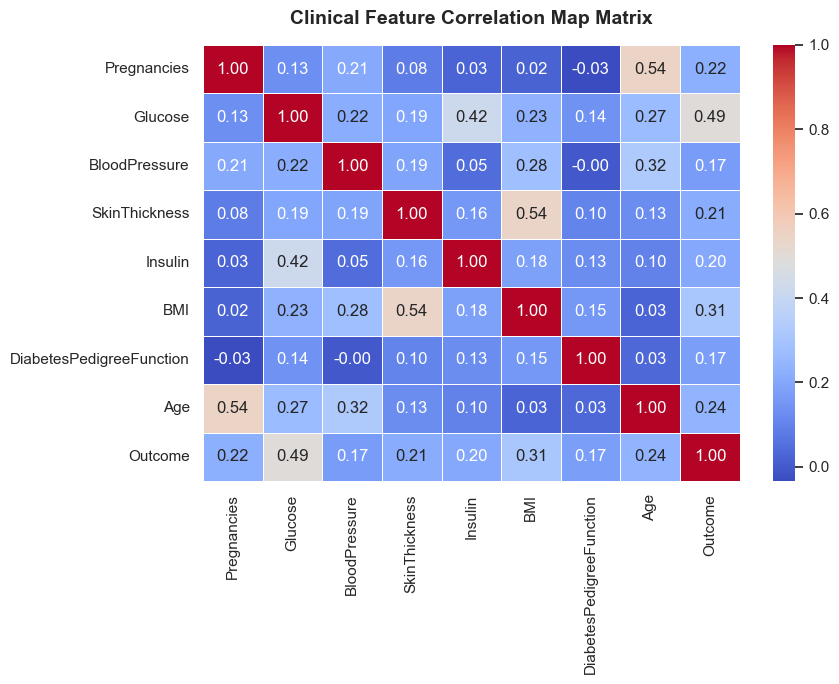

C:\Users\HP\AppData\Local\Temp\ipykernel_30228\493479230.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
C:\Users\HP\AppData\Local\Temp\ipykernel_30228\493479230.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])


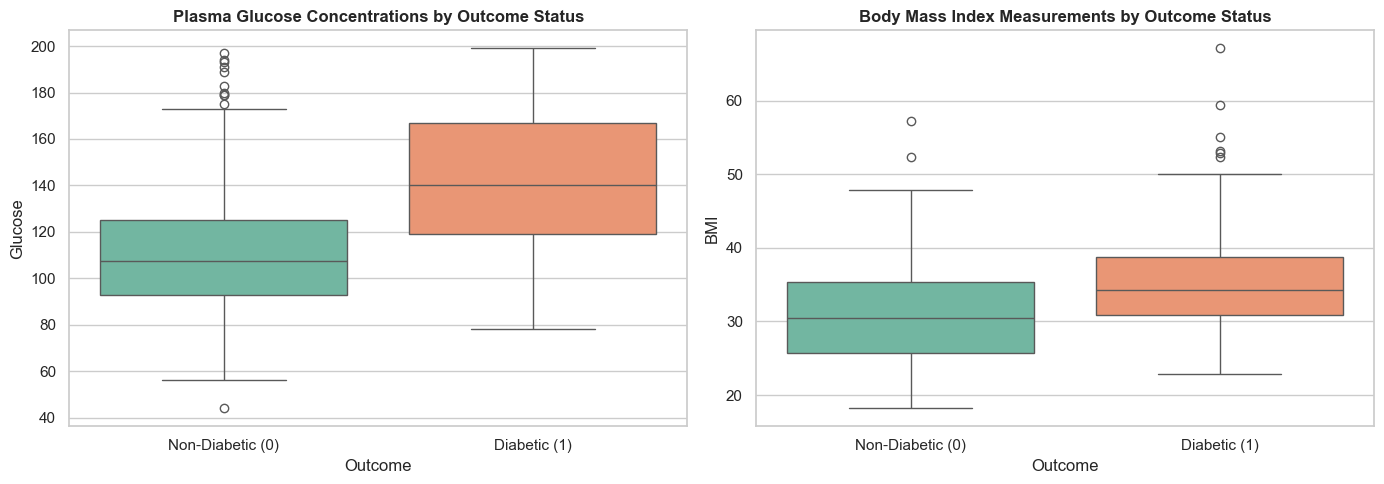

In [5]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1: Feature Correlation Heatmap Matrix
plt.figure(figsize=(9, 7))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Clinical Feature Correlation Map Matrix', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# 2: Distribution Boxplots vs Target Outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Glucose Levels vs Outcome Status
sns.boxplot(ax=axes[0], x='Outcome', y='Glucose', data=df, hue='Outcome', palette='Set2', legend=False)
axes[0].set_title('Plasma Glucose Concentrations by Outcome Status', fontsize=12, weight='bold')
axes[0].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])

# Plot B: BMI Measurements vs Outcome Status
sns.boxplot(ax=axes[1], x='Outcome', y='BMI', data=df, hue='Outcome', palette='Set2', legend=False)
axes[1].set_title('Body Mass Index Measurements by Outcome Status', fontsize=12, weight='bold')
axes[1].set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])

plt.tight_layout()
plt.show()


**Task 5: Predictive Modeling & Performance Evaluation**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Generating predictions on test data
y_pred = model.predict(X_test_scaled)

# --- Task 5 Evaluation Deliverables ---
print("--- MODEL ACCURACY PERFORMANCE ---")
print(f"🎯 Total Prediction Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\n--- DETAILED CLINICAL REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic (0)', 'Diabetic (1)']))

# Feature Importance Extract
importance = pd.DataFrame({
    'Clinical Feature': X.columns,
    'Impact Score (Weight)': model.coef_[0]
}).sort_values(by='Impact Score (Weight)', ascending=False)

print("\n--- FEATURE IMPORTANCE RANKING ---")
print(importance.to_string(index=False))


--- MODEL ACCURACY PERFORMANCE ---
🎯 Total Prediction Accuracy Score: 70.78%

--- DETAILED CLINICAL REPORT ---
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.75      0.82      0.78       100
    Diabetic (1)       0.60      0.50      0.55        54

        accuracy                           0.71       154
       macro avg       0.68      0.66      0.67       154
    weighted avg       0.70      0.71      0.70       154


--- FEATURE IMPORTANCE RANKING ---
        Clinical Feature  Impact Score (Weight)
                 Glucose               1.182511
                     BMI               0.688735
             Pregnancies               0.377502
DiabetesPedigreeFunction               0.233386
                     Age               0.147798
           SkinThickness               0.028225
           BloodPressure              -0.044066
                 Insulin              -0.066157
